<a href="https://colab.research.google.com/github/oxedanda/AVCAD_Exercises/blob/main/exercise_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

In [24]:
#Data loading and cleaning

df = pd.read_csv(
    "/content/EFIplus_medit.zip",
    compression="zip",
    sep=";"
)

In [25]:
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)

df.rename(columns={"Sum of Run1_number_all": "Total_fish_individuals"}, inplace=True)

df.columns = list(map(str, df.columns))

In [26]:
df.shape
df.columns.tolist()
df["Catchment_name"].value_counts(dropna=False)

,count
Catchment_name,
Ebro,736
Galiza-Norte,709
Minho,707
Tejo,509
Cantabrica,502
Douro,401
Guadia,313
Catala,242
Tevere,106


In [27]:
#Selection of groups - filter the dataset to include only sites from the four basins:

basins = ["Douro", "Tejo", "Mondego", "Minho"]
work = df[df["Catchment_name"].isin(basins)].copy()

In [28]:
# Preparation of environmental variables - select a subset of quantitative environmental variables and removed rows with missing values:

env_vars = [
    "Altitude",
    "Actual_river_slope",
    "Natural_sediment",
    "Elevation_mean_catch",
    "prec_ann_catch",
    "temp_ann",
    "temp_jan",
    "temp_jul"
]

work = work.dropna(subset=env_vars)
work.shape

(1497, 154)

In [29]:
X = work[env_vars]
y = work["Catchment_name"]

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_scaled, y)

scores = pd.DataFrame(
    X_lda,
    columns=[f"LD{i+1}" for i in range(X_lda.shape[1])]
)
scores["Catchment_name"] = y.reset_index(drop=True)

scores.head()

,LD1,LD2,LD3,Catchment_name
0,0.978060,-1.540667,0.285133,Tejo
1,1.490403,-1.027228,0.404356,Tejo
2,0.577130,-1.224258,0.515798,Tejo
3,0.643862,-1.548454,0.021829,Tejo
4,0.689321,-1.407161,0.447177,Tejo


In [34]:
loadings = pd.DataFrame(
    lda.scalings_[:, :2],
    index=env_vars,
    columns=["LD1", "LD2"]
)

loadings.sort_values("LD1", key=lambda s: s.abs(), ascending=False)

,LD1,LD2
Altitude,3.632263,0.736241
temp_ann,3.065842,4.259594
temp_jan,1.295472,-1.145006
temp_jul,0.556204,-1.470803
prec_ann_catch,-0.465320,0.840592
Elevation_mean_catch,0.272445,0.941460
Actual_river_slope,0.107311,0.060644
Natural_sediment,-0.014860,-0.125003


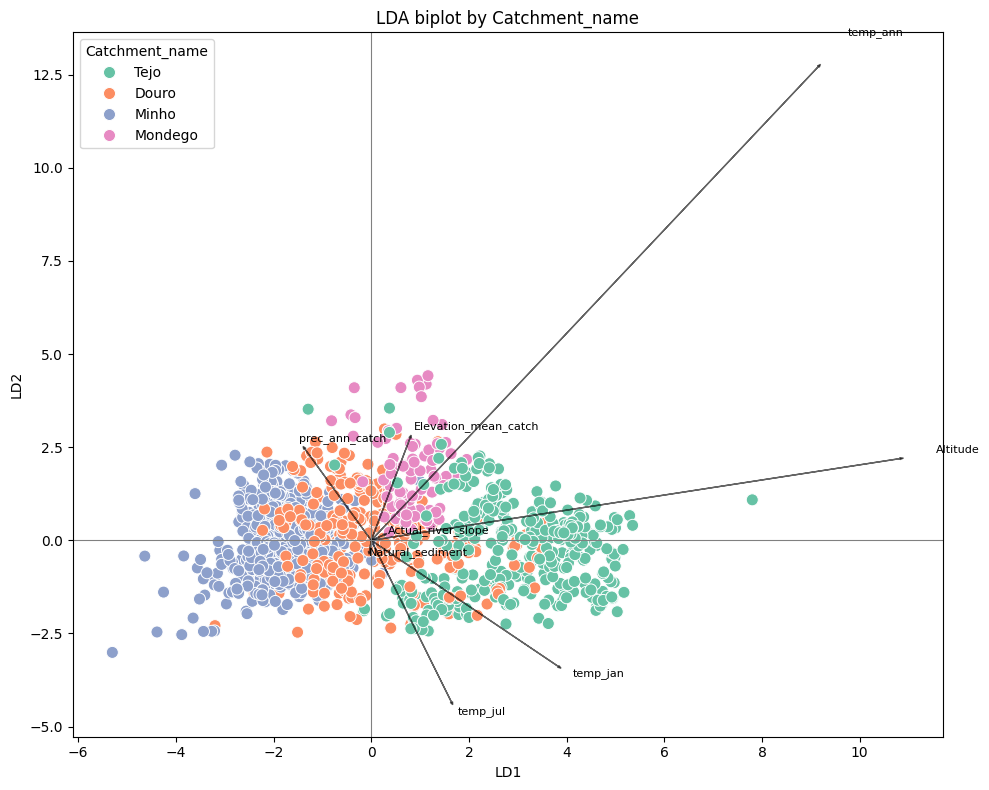

In [35]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=scores,
    x="LD1",
    y="LD2",
    hue="Catchment_name",
    palette="Set2",
    s=75
)

scale_factor = 3

for var in loadings.index:
    x = loadings.loc[var, "LD1"] * scale_factor
    y = loadings.loc[var, "LD2"] * scale_factor
    plt.arrow(0, 0, x, y, color="black", alpha=0.6, head_width=0.05, length_includes_head=True)
    plt.text(x * 1.06, y * 1.06, var, fontsize=8)

plt.axhline(0, color="grey", lw=0.8)
plt.axvline(0, color="grey", lw=0.8)
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA biplot by Catchment_name")
plt.legend(title="Catchment_name")
plt.tight_layout()
plt.show()

In [36]:
import plotly.express as px

fig = px.scatter(
    scores,
    x="LD1",
    y="LD2",
    color="Catchment_name",
    title="Interactive LDA plot",
    width=900,
    height=650
)

fig.show()

use Linear Discriminant Analysis (LDA) to examine how multiple quantitative environmental variables jointly discriminate among four predetermined groups: the Douro, Tejo, Mondego, and Minho basins. LDA is a supervised dimension-reduction method that finds linear combinations of variables (discriminant functions) that maximize separation between groups while minimizing variation within groups.

What LDA does
Given:

a set of quantitative environmental variables (e.g. altitude, river slope, precipitation, temperature, barriers, water quality indicators), and

a grouping variable (Catchment_name) with predefined groups (Douro, Tejo, Mondego, Minho),

LDA:

computes the centroid (mean point) of each group in the space of the environmental variables;

finds linear combinations of the variables (called discriminant functions LD1, LD2, …) that:

maximize the distance between group centroids, and

minimize the spread of points within each group;

projects all sites onto these discriminant functions, producing a lower-dimensional representation where group separation is as clear as possible.

With
k
=
4
k=4 groups, the maximum number of discriminant functions is
k
−
1
=
3
k−1=3. In practice, we usually visualize the first two (LD1 and LD2), which capture the most important separation between basins.

Variables used
We selected a set of quantitative environmental variables that describe:

physical catchment characteristics (e.g. Altitude, Elevation_mean_catch, Actual_river_slope),

climate (e.g. prec_ann_catch, temp_ann, temp_jan, temp_jul),

hydromorphological pressures (e.g. Barriers_*, Impoundment, Hydropeaking, Water_abstraction, Channelisation, etc.),

water quality (e.g. Water_quality_index, Eutrophication, Organic_pollution, Toxic_substances, Acidification).

These variables are the same type of quantitative environmental descriptors used in previous exercises to characterize catchments.